# Portage C & pipeline expérimental board — Recueil des figures

**Titre** : Du modèle Python au capteur intelligent — portage C et expériences sur NUCLEO-F439ZI  
**Auteur** : Léonard Rivals — ISAE-SUPAERO / ENAC / Edge Spectrum

Ce notebook rassemble les **schémas** de la présentation technique « portage C & pipeline expérimental »,
dans l'ordre des slides défini dans [`03_structure_portage.md`](03_structure_portage.md).
Le texte parlé associé est dans [`04_script_portage.md`](04_script_portage.md).

Les figures sont les PNG schématiques générés par `scripts/generate_portage_plots.py` dans
`docs/figures/presentation_board/` (préfixe `portage_`). Ce notebook ne les régénère pas : il les
**collecte** pour relecture. Exécuter *Run All* pour tout afficher.

> Si une figure manque, un avertissement s'affiche à sa place (le notebook ne plante pas).

## Configuration

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def _find_figures_root() -> Path:
    """Localise le dossier docs/figures quel que soit le cwd de lancement."""
    here = Path.cwd()
    for base in [here, *here.parents]:
        cand = base / "docs" / "figures"
        if cand.exists():
            return cand
        cand = base / "figures"
        if (cand / "presentation_board").exists():
            return cand
    return Path("..") / "figures"


FIG_DIR = _find_figures_root()
FIG_BOARD = FIG_DIR / "presentation_board"
print(f"Dossier figures : {FIG_DIR.resolve()}")
print(f"Existe : {FIG_DIR.exists()}  |  presentation_board : {FIG_BOARD.exists()}")


def show(filename: str, caption: str = "", width: int | None = None) -> None:
    """Affiche une figure schématique du portage avec une légende."""
    path = FIG_BOARD / filename
    if caption:
        display(Markdown(f"*{caption}*"))
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"⚠️ **Figure manquante** : `{path}` — lancer `python scripts/generate_portage_plots.py`"))

Dossier figures : /home/leonard/Documents/ENAC/cl-embedded/docs/figures
Existe : True  |  presentation_board : True


---
## Slide 1 / 9 / 12 — Flux de données bout-en-bout
Fil rouge de la présentation : du dataset au JSON d'expérience (sert aussi aux slides 9 et 12).

*Flux bout-en-bout : dataset → features → Z-score → trame UART → carte → réponse → experiments/.*

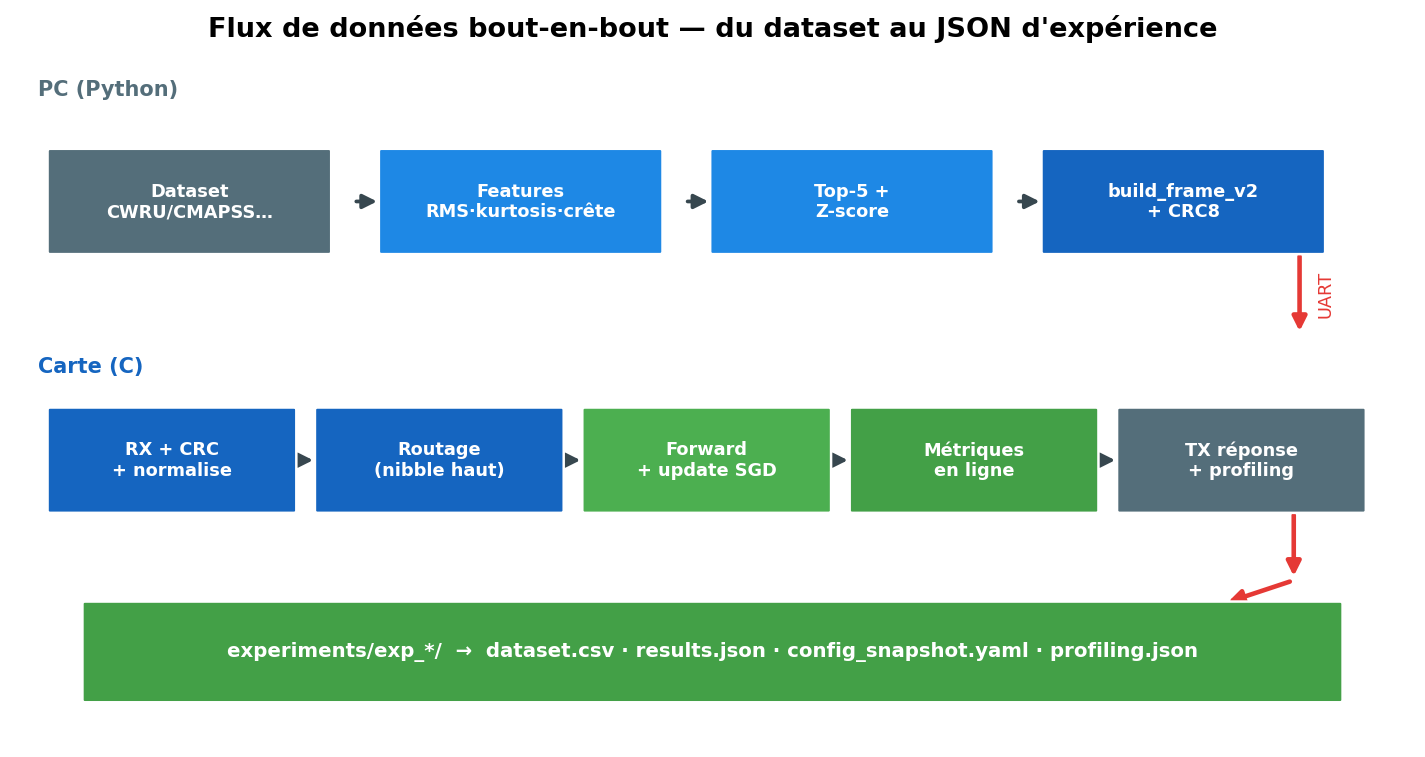

In [2]:
show("portage_04_dataflow.png", caption="Flux bout-en-bout : dataset → features → Z-score → trame UART → carte → réponse → experiments/.")

---
## Slide 4 — Architecture firmware
pipeline.c orchestre, têtes modèles exécutent ; trois zones mémoire Flash / .bss / stack.

*Architecture firmware NUCLEO-F439ZI : routeur + têtes modèles + gestion mémoire.*

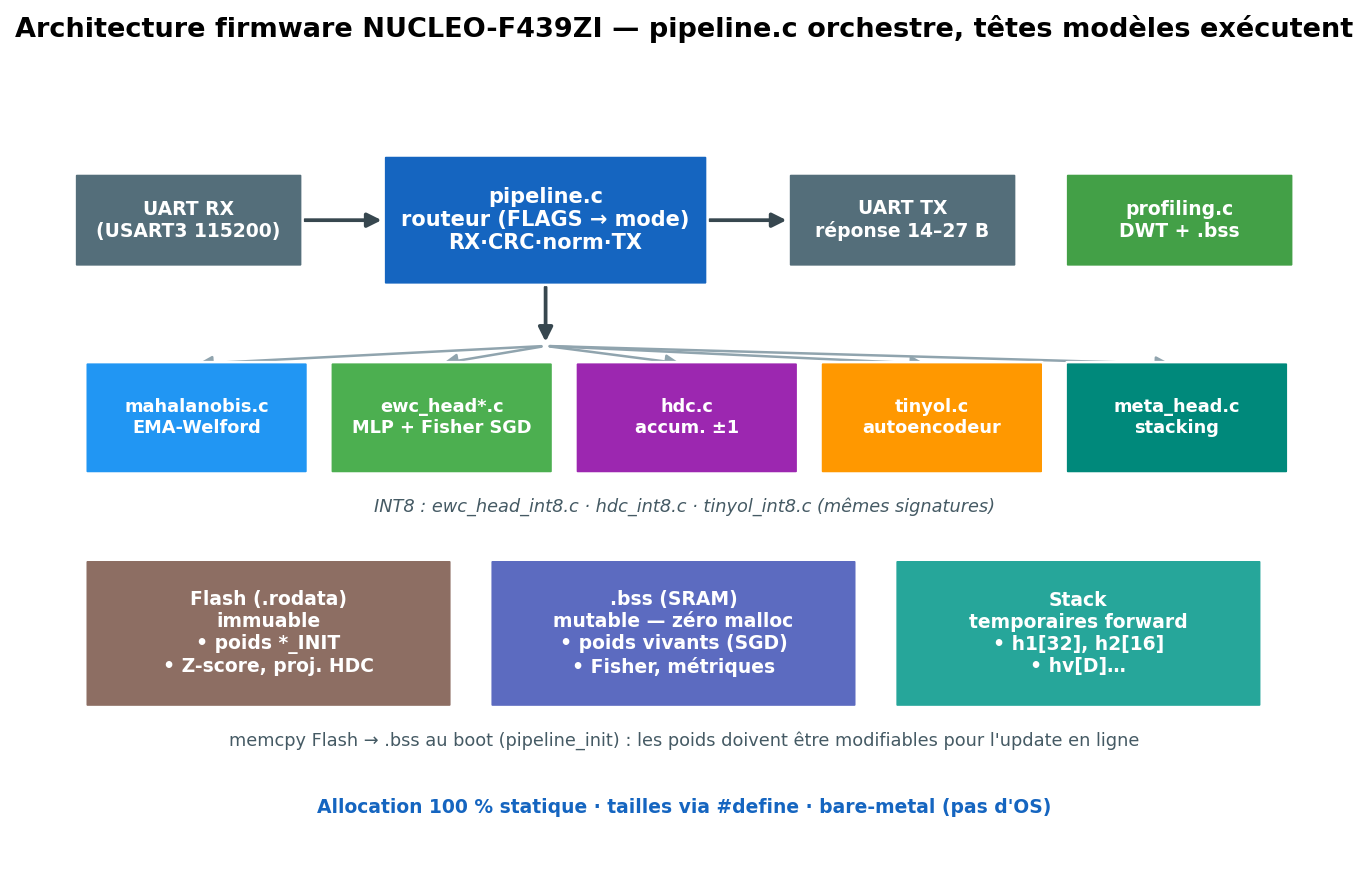

In [3]:
show("portage_01_firmware_arch.png", caption="Architecture firmware NUCLEO-F439ZI : routeur + têtes modèles + gestion mémoire.")

---
## Slide 5 — Export des poids Python → C
Workflow : .pt/.pkl → export_weights_*.py → model_weights*.h → memcpy Flash→.bss.

*Export des poids : header C généré, jamais édité à la main ; Flash immuable vs .bss mutable.*

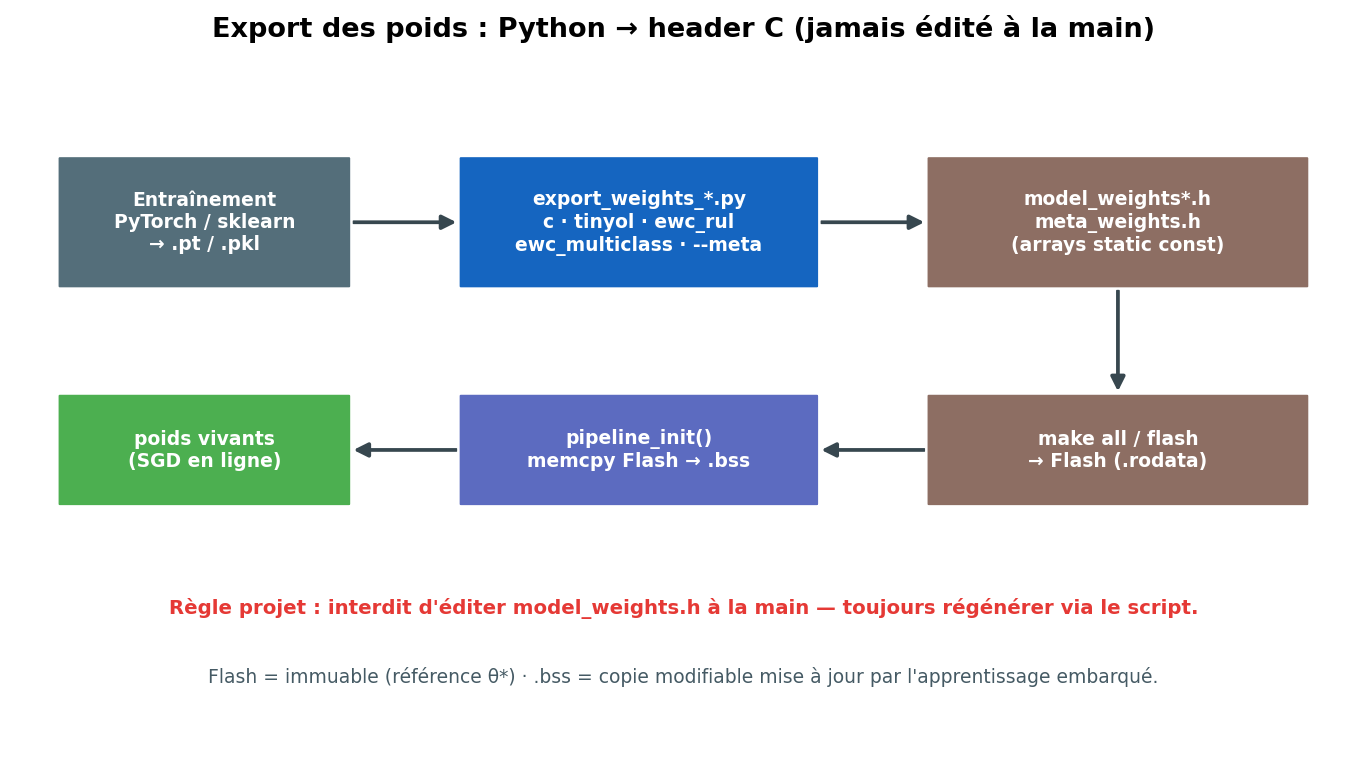

In [4]:
show("portage_05_weights_export.png", caption="Export des poids : header C généré, jamais édité à la main ; Flash immuable vs .bss mutable.")

---
## Slide 7 & 10 — Trame UART & tailles de réponse
Trame requête octet par octet (32 B pour N=5) + tailles de réponse par mode (slide 10).

*Trame requête et réponses v2/v3/DUAL/PAIR/TRIPLE — offsets et formats struct exacts.*

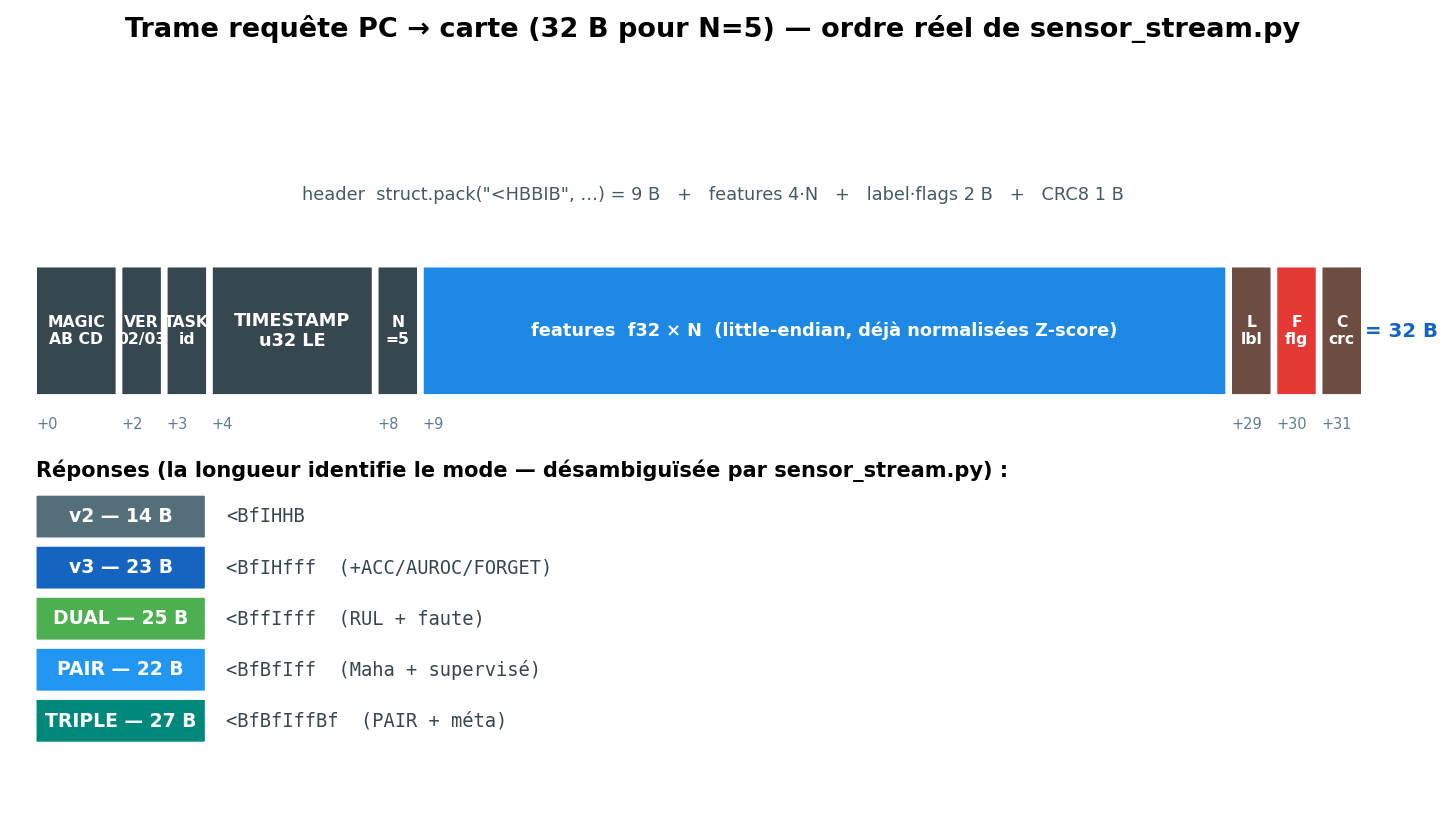

In [5]:
show("portage_02_uart_frame.png", caption="Trame requête et réponses v2/v3/DUAL/PAIR/TRIPLE — offsets et formats struct exacts.")

---
## Slide 8 — FLAGS : dispatch par nibble
Nibble bas = actions ; nibble haut = mode ; ordre d'évaluation exact-match.

*Table des modes (single → composites → ensembles) et ordre de dispatch.*

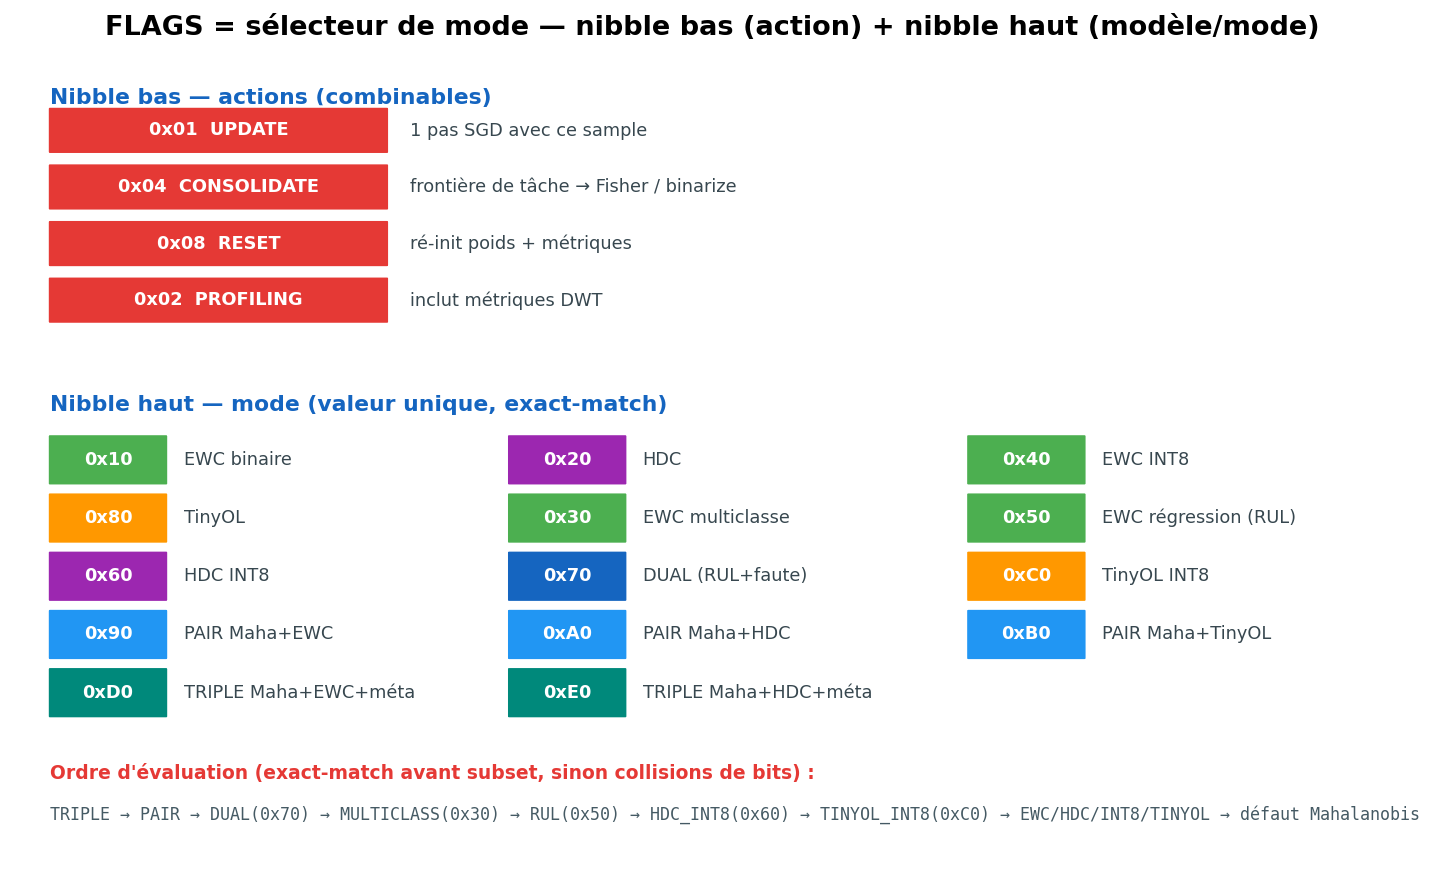

In [6]:
show("portage_03_mode_dispatch.png", caption="Table des modes (single → composites → ensembles) et ordre de dispatch.")

---
## Slide 11 — Profiling embarqué
Latence via DWT CYCCNT, RAM via symboles linker _ebss − _sbss.

*Profiling : chronométrage DWT (RX→TX) et calcul de la taille .bss.*

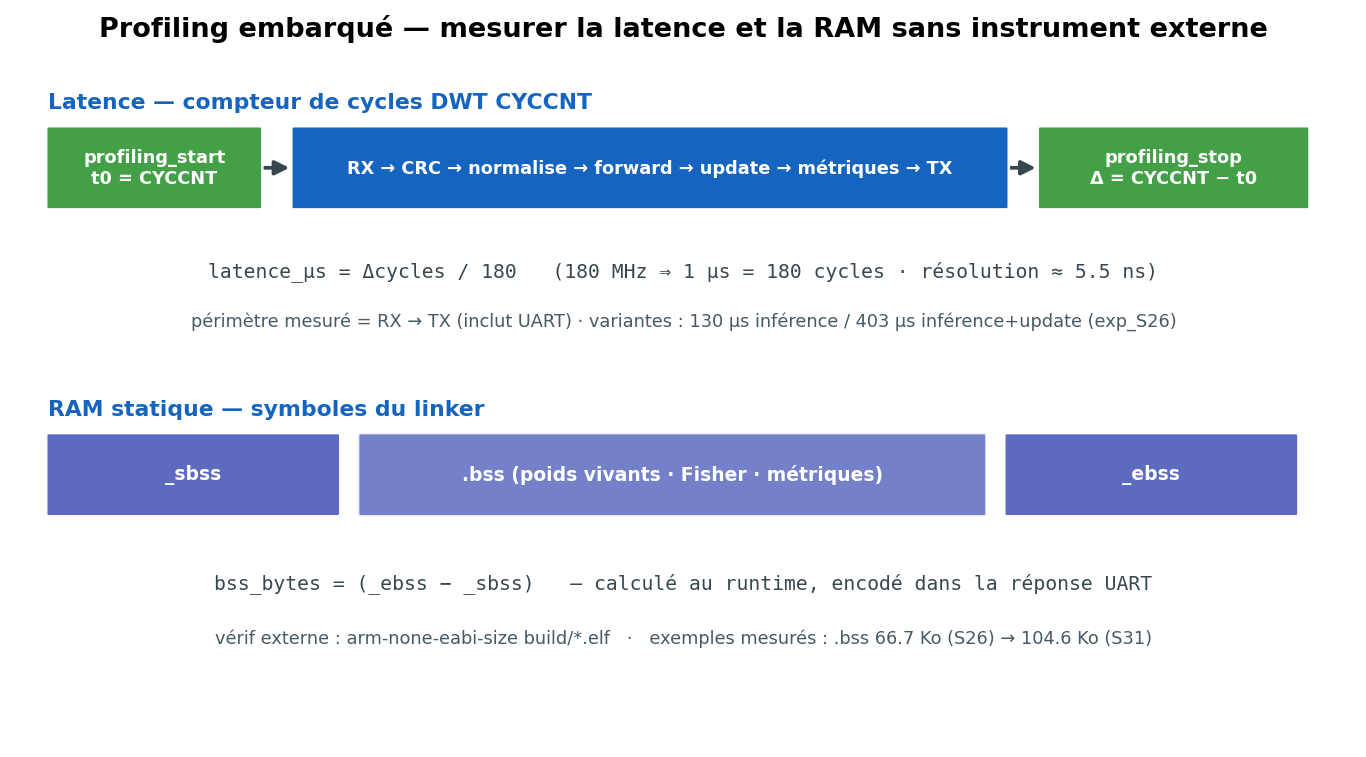

In [7]:
show("portage_06_profiling.png", caption="Profiling : chronométrage DWT (RX→TX) et calcul de la taille .bss.")

---
## Annexe — réutilisation des figures existantes

Les schémas suivants de la présentation séminaire restent pertinents en secours (Q&R) :
`08_firmware_architecture.png`, `06_memory_breakdown.png`. L'ancien `09_uart_protocol.png` est **périmé**
(antérieur aux modes DUAL/PAIR/TRIPLE) — préférer `portage_02_uart_frame.png` ci-dessus.

*(Annexe) Schéma firmware de la présentation séminaire.*

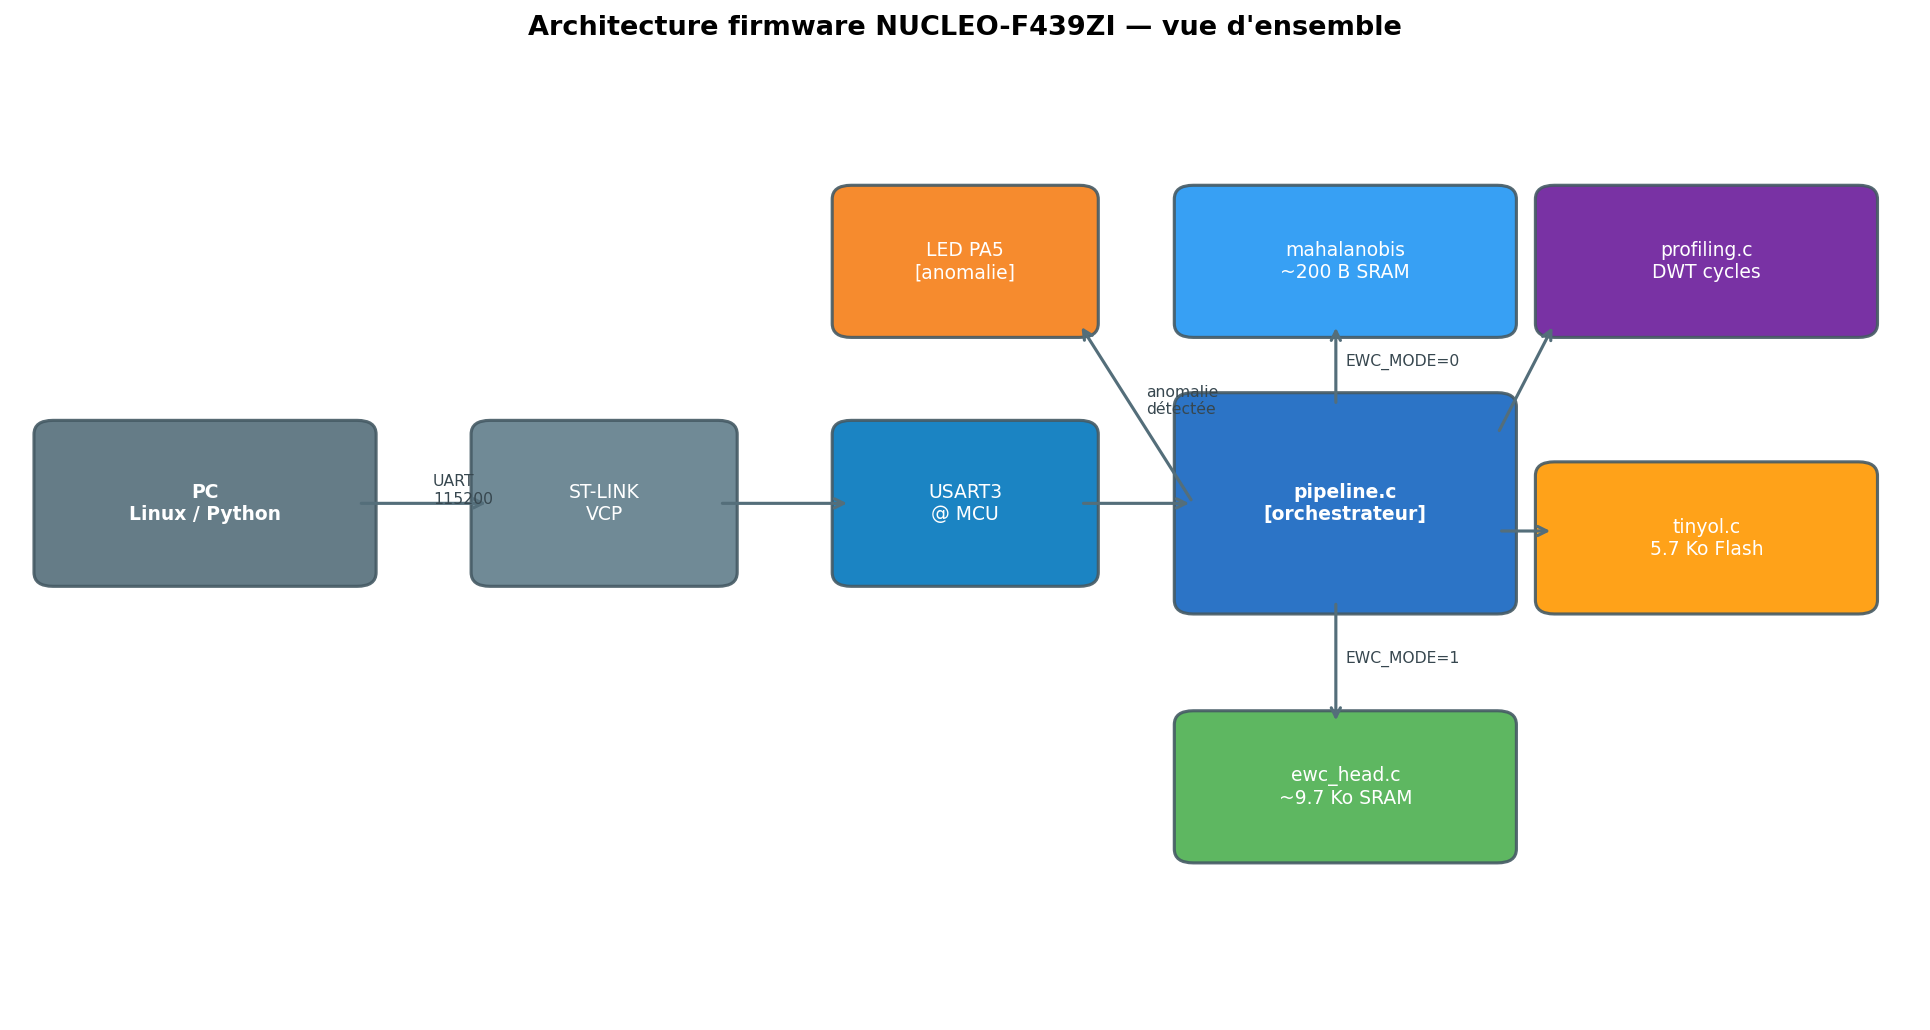

In [8]:
show("08_firmware_architecture.png", caption="(Annexe) Schéma firmware de la présentation séminaire.")